# **Data Quality Assessment**  

First task is to evaluate the quality of the dataset by assessing it based on: **accuracy, completeness, consistency, and validity**. This helps identify missing values, formatting inconsistencies, and incorrect entries that may affect the analysis. Establishing the quality of the data ensures that the later analysis is based on reliable and well-structured information.

---

---

## 1. Initial Setup

This section prepares the environment for the analysis by importing the required libraries and setting up the workspace. These tools will be used throughout the notebook to load, inspect, and evaluate the dataset.

In [23]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from pathlib import Path

pd.set_option("display.max_columns", None)

---

## 2. Data Loading and Initial Exploration

The dataset is loaded into the Python environment and inspected to understand its structure. Reviewing column names, data types, and sample observations helps identify any immediate irregularities in the data.

### 2.1 - Load Dataset

In [6]:
# Load the dataset

data_path = Path("../data/raw_credit_applications.json")

df = pd.read_json(data_path)

# Show dataset shape
df.shape

(502, 8)

### 2.2 - Dataset Shape

In [8]:
# Load raw JSON
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Flatten nested structure into columns
df_original = pd.json_normalize(raw_data)

# Working copy for analysis/cleaning
df = df_original.copy()

print("Dataset loaded successfully")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

df.head()

Dataset loaded successfully
Shape: 502 rows, 21 columns


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,78000,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,103000,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,57000,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


### 2.3 - Quick exploration

In [ ]:
df.info()
df.describe(include="all").T.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               502 non-null    object 
 1   spending_behavior                 502 non-null    object 
 2   processing_timestamp              62 non-null     object 
 3   applicant_info.full_name          502 non-null    object 
 4   applicant_info.email              502 non-null    object 
 5   applicant_info.ssn                497 non-null    object 
 6   applicant_info.ip_address         497 non-null    object 
 7   applicant_info.gender             501 non-null    object 
 8   applicant_info.date_of_birth      501 non-null    object 
 9   applicant_info.zip_code           501 non-null    object 
 10  financials.annual_income          497 non-null    object 
 11  financials.credit_history_months  502 non-null    int64  
 12  financia

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
_id,502,500,app_001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spending_behavior,502,496,"[{'category': 'Insurance', 'amount': 171}]",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
processing_timestamp,62,4,2024-01-15T00:00:00Z,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.full_name,502,475,Susan Flores,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.email,502,494,,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.ssn,497,494,652-70-5530,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.ip_address,497,496,192.168.91.142,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.gender,501,5,Male,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.date_of_birth,501,494,,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.zip_code,501,196,10048,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## 3. Completeness Analysis

This section evaluates the completeness of the dataset by identifying missing values across variables. Detecting gaps in the data helps determine where information may be incomplete or unavailable.

### 3.1 - Missing Values

In [10]:
# Count missing values per column
missing_counts = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into one table
missing_summary = pd.DataFrame({
    "Missing Values": missing_counts,
    "Missing Percentage (%)": missing_percent
})

# Sort by most missing
missing_summary = missing_summary.sort_values(by="Missing Percentage (%)", ascending=False)

missing_summary

,Missing Values,Missing Percentage (%)
notes,500,99.601594
financials.annual_salary,497,99.003984
loan_purpose,452,90.039841
processing_timestamp,440,87.649402
decision.rejection_reason,292,58.167331
decision.interest_rate,210,41.832669
decision.approved_amount,210,41.832669
applicant_info.ssn,5,0.996016
applicant_info.ip_address,5,0.996016
financials.annual_income,5,0.996016


### 3.2 Missing Data Visualization

This subsection visualizes the columns with the highest percentage of missing values. This makes it easier to identify which variables may require cleaning, imputation, or removal.

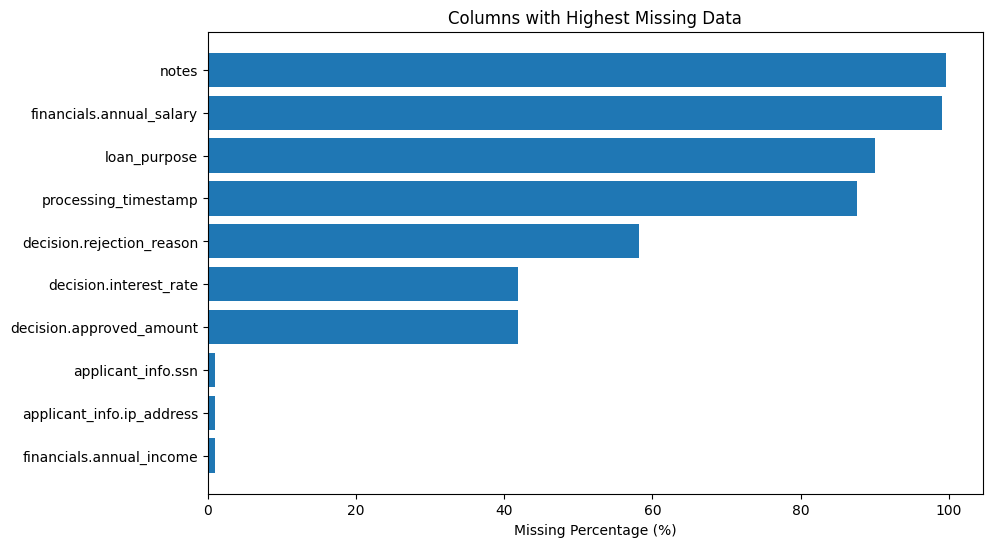

In [ ]:
top_missing = missing_summary.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_missing.index, top_missing["Missing Percentage (%)"])
plt.xlabel("Missing Percentage (%)")
plt.title("Columns with Highest Missing Data")
plt.gca().invert_yaxis()

plt.show()

---

## 4. Consistency Analysis

Consistency refers to whether data values follow expected formats and logical rules across the dataset.

In this section, we evaluate whether key identifiers are unique and whether values are consistently recorded across variables.

### 4.1 Application ID Uniqueness

Each loan application should have a unique identifier. This check ensures that there are no duplicate application IDs in the dataset.

In [12]:
# Check for duplicate application IDs

duplicate_ids = df["_id"].duplicated().sum()

print("Number of duplicate application IDs:", duplicate_ids)

Number of duplicate application IDs: 2


Observation: 

The dataset contains duplicate application IDs. Since each loan application should have a unique identifier, the presence of duplicate `_id` values indicates a potential data consistency issue. These records will be inspected further to determine whether they represent duplicated entries or legitimate repeated records.

In [13]:
# View the duplicate records

duplicate_records = df[df["_id"].duplicated(keep=False)]

duplicate_records

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
354,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION
383,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,102000,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,NaN
455,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,NaN,NaN,NaN,NaN,NaN,102000,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR


Observation: 

Two application IDs appear more than once in the dataset (`app_042` and `app_001`). 

After inspecting the records, the duplicated rows appear to be identical entries. Since each application should be represented only once, these duplicated records will be removed to maintain dataset consistency.

In [17]:
# Count missing values per row (lower = better)
df["_missing_count"] = df.isna().sum(axis=1)

# Sort so the "best" row per _id comes first
df = df.sort_values(by=["_id", "_missing_count"])

# Keep the most complete row for each _id
df = df.drop_duplicates(subset="_id", keep="first").copy()

# Cleanup
df = df.drop(columns=["_missing_count"])

print("Shape after resolving duplicates by completeness:", df.shape)

duplicate_ids_after = df["_id"].duplicated().sum()

print("Number of duplicate application IDs after cleaning:", duplicate_ids_after)

Shape after resolving duplicates by completeness: (500, 21)
Number of duplicate application IDs after cleaning: 0


Observation:

After inspecting the duplicated application IDs, the duplicated records appear to represent repeated entries of the same loan applications rather than legitimate separate submissions. In the case of Joseph Lopez, both records contain identical values across all fields, indicating a clear duplicate. For Stephanie Nguyen, one record contains missing values while the other contains more complete information.

Since each loan application should be represented only once in the dataset, duplicate records were resolved by keeping the most complete version of each application and removing the redundant entries. This ensures that each _id remains unique and improves the overall consistency of the dataset.

### 4.2 - Check for Duplicate Emails

In [18]:
duplicate_emails = df["applicant_info.email"].duplicated().sum()

print("Number of duplicated applicant emails:", duplicate_emails)

Number of duplicated applicant emails: 6


In [19]:
duplicate_email_rows = df[df["applicant_info.email"].duplicated(keep=False)]

duplicate_email_rows[["_id", "applicant_info.full_name", "applicant_info.email"]].sort_values("applicant_info.email")

,_id,applicant_info.full_name,applicant_info.email
26,app_075,Margaret Williams,
275,app_120,Carolyn Martin,
462,app_165,Brandon Moore,
297,app_268,Larry Williams,
448,app_350,Linda Adams,
298,app_377,Anna White,
187,app_413,Anthony Jackson,


Observation:

After resolving duplicate application IDs, an additional check was performed to identify repeated applicant email addresses. The analysis revealed that several email addresses appear multiple times in the dataset.

This does not necessarily indicate a data quality issue, as a single applicant may submit multiple loan applications over time. Therefore, these records were not removed. However, identifying repeated emails helps highlight potential repeated applicants and provides additional context about the dataset.

Overall, the consistency checks confirm that each application identifier is now unique while acknowledging that certain applicant attributes may legitimately appear multiple times.

---

## 5. Accuracy 

Accuracy evaluates whether the values recorded in the dataset are reasonable and believable given the context of loan applications. Since no external ground truth dataset is available for comparison, accuracy is assessed through plausibility checks. These checks identify values that fall outside realistic ranges or violate logical expectations, such as negative income values or credit scores outside the typical range. Records that fail these checks are flagged for further inspection.

### 5.1 - Numerical Plausability Checks

In [20]:
numeric_columns = df.select_dtypes(include="number").columns

df[numeric_columns].describe()

,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.interest_rate,decision.approved_amount,financials.annual_salary
count,500.000000,500.000000,500.000000,292.000000,292.000000,5.000000
mean,50.444000,0.245520,29579.530000,4.564726,47845.890411,69200.000000
std,31.289822,0.136148,16745.805308,1.162866,18103.754530,22664.950915
min,-10.000000,0.050000,-5000.000000,2.500000,15000.000000,45000.000000
25%,27.000000,0.150000,17387.250000,3.500000,34000.000000,46000.000000
50%,48.500000,0.230000,27399.000000,4.550000,48000.000000,75000.000000
75%,72.000000,0.342500,38281.750000,5.600000,62250.000000,86000.000000
max,133.000000,1.850000,88078.000000,6.500000,80000.000000,94000.000000


### 5.2 - Detect Implausible Financial Values

Based on the numerical summary statistics, several values appear to fall outside realistic ranges. For example, credit history duration should not be negative and savings balances should generally not fall below zero. Additionally, extremely high debt-to-income ratios may indicate data entry errors or unusual financial situations.

To identify these potential inaccuracies, rule-based checks are applied to flag records that violate expected financial constraints.

In [21]:
# Flag implausible values
accuracy_flags = pd.DataFrame(index=df.index)

# Negative credit history months
accuracy_flags["invalid_credit_history"] = df["financials.credit_history_months"] < 0

# Negative savings balance
accuracy_flags["negative_savings_balance"] = df["financials.savings_balance"] < 0

# Extremely high debt-to-income ratio
accuracy_flags["extreme_debt_to_income"] = df["financials.debt_to_income"] > 1

# Count flagged records
accuracy_summary = accuracy_flags.sum()

accuracy_summary

invalid_credit_history      2
negative_savings_balance    1
extreme_debt_to_income      1
dtype: int64

### 5.3 - Inspect Flagged Records

To better understand the potential inaccuracies identified in the previous step, the records that triggered the plausibility checks are inspected directly. This allows us to verify whether the flagged values appear to be data entry errors or unusual but possible financial situations.

In [22]:
# Identify rows with at least one accuracy issue
flagged_rows = accuracy_flags.any(axis=1)

# Display relevant columns for inspection
df.loc[flagged_rows, [
    "_id",
    "applicant_info.full_name",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance"
]]

,_id,applicant_info.full_name,financials.credit_history_months,financials.debt_to_income,financials.savings_balance
137,app_043,Daniel King,-10,0.06,53098
162,app_156,Jessica Green,-3,0.21,13641
159,app_290,Stephanie Perez,39,0.27,-5000
316,app_402,Heather Flores,27,1.85,37281


### 5.4 Analysis

The plausibility checks identified several records containing potentially inaccurate financial values. Two applications contain negative credit history durations, which is not logically possible and likely indicates a data entry or preprocessing error. One application contains a negative savings balance, which may also represent incorrect data recording. Additionally, one record exhibits an extremely high debt-to-income ratio, suggesting that the applicant's reported debt significantly exceeds their income.

In total, four applications were flagged by these checks. These records were not automatically removed from the dataset, as further validation would be required to determine whether they represent true errors or unusual financial situations. However, flagging these cases highlights potential accuracy issues that should be reviewed before using the data for analytical or modeling purposes.

---

## 6. Validity Check

Validity refers to whether the data values conform to the expected formats, types, and structural rules defined for each field. In this dataset, validity checks focus on verifying that certain attributes follow standardized formats, such as email addresses, Social Security Numbers, and IP addresses. Ensuring that these fields meet expected patterns helps identify formatting errors, inconsistent data entry, or corrupted records that could cause issues in downstream processing or analysis.

### 6.1 - Email Validation

In [24]:
# Simple email format pattern
email_pattern = r"^[^@]+@[^@]+\.[^@]+$"

# Flag invalid emails
invalid_emails = ~df["applicant_info.email"].astype(str).str.match(email_pattern)

# Count invalid emails
invalid_email_count = invalid_emails.sum()

invalid_email_count

np.int64(10)

### 6.2 - Inspect Invalid Emails

After identifying records that do not match the expected email format, the flagged entries are inspected directly. This helps determine whether the issue results from formatting errors, missing values, or other data inconsistencies.

In [25]:
df.loc[invalid_emails, [
    "_id",
    "applicant_info.full_name",
    "applicant_info.email"
]]

,_id,applicant_info.full_name,applicant_info.email
276,app_068,Emily Lopez,john.doe@invalid
26,app_075,Margaret Williams,
275,app_120,Carolyn Martin,
369,app_146,Amy Flores,sarah.smith@
462,app_165,Brandon Moore,
297,app_268,Larry Williams,
181,app_299,Samuel Gonzalez,test.user.outlook.com
448,app_350,Linda Adams,
298,app_377,Anna White,
187,app_413,Anthony Jackson,


Observation:

The email format validation identified several records that do not conform to the expected structure of an email address. Examples include incomplete addresses, missing domain components, and values that do not contain the required "@" symbol. Additionally, some records contain missing email values.

In total, ten applications were flagged during the validation process. These issues likely originate from incomplete data entry or formatting inconsistencies during data collection. While these records were not automatically corrected or removed, identifying them highlights potential data validity issues that should be addressed before using the dataset in production systems or analytical workflows.

### 6.3 - SSN Validation

Social Security Numbers (SSNs) follow a standardized format in the United States consisting of nine digits typically written as XXX-XX-XXXX. Validating the SSN format helps identify incorrectly formatted or corrupted entries that may have occurred during data entry or data ingestion.

In [26]:
# SSN format pattern (XXX-XX-XXXX)
ssn_pattern = r"^\d{3}-\d{2}-\d{4}$"

# Flag invalid SSNs
invalid_ssn = ~df["applicant_info.ssn"].astype(str).str.match(ssn_pattern)

# Count invalid SSNs
invalid_ssn_count = invalid_ssn.sum()

invalid_ssn_count

np.int64(4)

### 6.4 - Inspect Invalid SSNs

After identifying SSNs that do not follow the expected format, the flagged records are inspected to understand the nature of the formatting issues and determine whether the values are missing, incomplete, or incorrectly structured.

In [27]:
df.loc[invalid_ssn, [
    "_id",
    "applicant_info.full_name",
    "applicant_info.ssn"
]]

,_id,applicant_info.full_name,applicant_info.ssn
26,app_075,Margaret Williams,NaN
275,app_120,Carolyn Martin,NaN
462,app_165,Brandon Moore,NaN
297,app_268,Larry Williams,NaN


Observation:

The validity checks focused on verifying whether key fields follow expected formats, including email addresses and Social Security Numbers. The email validation identified several records that do not conform to the expected email structure. These include incomplete addresses, missing domain components, or values that do not contain the required "@" symbol. In some cases, the email field is entirely missing.

The SSN format validation did not reveal incorrectly structured SSNs; however, four records contain missing SSN values. While this does not represent a formatting error, it highlights a completeness issue in the dataset.

Overall, these checks demonstrate that while most structured fields follow the expected format, several records contain missing or improperly formatted values that should be addressed before the dataset is used for further analysis or production systems.

---

## 7. Summary of Data Quality Issues

This section summarizes the key findings from the data quality assessment. The identified issues provide insight into potential cleaning or preprocessing steps before moving to further analysis.